# Tutorial: dsbro Quickstart

Audience:
- Data scientists working in notebooks who want one import for setup, EDA, prep, viz, and baseline ML.

Prerequisites:
- Python, pandas, and a local editable install of `dsbro`.

Learning goals:
- By the end, the reader can load data, inspect it, build quick features, and run a simple leaderboard.


## Outline

1. Setup
2. Build a tiny example dataset
3. Run EDA and preprocessing
4. Train a baseline model
5. Next steps


In [4]:
# !pip install dsbro

In [5]:
from __future__ import annotations

import pandas as pd

import dsbro

dsbro.setup()
dsbro.about()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
dsbro 0.1.0
Your Data Science Bro. One import away.
Author: Muhammad Ibrahim Qasmi
Homepage: https://github.com/ibrahimqasmi/dsbro


'dsbro 0.1.0\nYour Data Science Bro. One import away.\nAuthor: Muhammad Ibrahim Qasmi\nHomepage: https://github.com/ibrahimqasmi/dsbro'

## Step 1 - Build a tiny tabular dataset

This synthetic example mixes numeric, categorical, datetime, and text features so you can exercise multiple dsbro modules in one notebook.


In [6]:
train = pd.DataFrame(
    {
        "age": [22, 35, 41, 28, 33, 45],
        "income": [35_000, 72_000, 88_000, 49_000, 61_000, 95_000],
        "city": ["lahore", "karachi", "lahore", "islamabad", "karachi", "lahore"],
        "signup_date": [
            "2024-01-05",
            "2024-02-14",
            "2024-02-20",
            "2024-03-01",
            "2024-03-11",
            "2024-03-19",
        ],
        "bio": [
            "Loves data science and Kaggle.",
            "ML engineer building dashboards.",
            "Enjoys notebooks and quick EDA.",
            "Learning feature engineering.",
            "Shipping models to production.",
            "Practices every day on tabular datasets.",
        ],
        "purchased": [0, 1, 1, 0, 1, 1],
    }
)

train


,age,income,city,signup_date,bio,purchased
0,22,35000,lahore,2024-01-05,Loves data science and Kaggle.,0
1,35,72000,karachi,2024-02-14,ML engineer building dashboards.,1
2,41,88000,lahore,2024-02-20,Enjoys notebooks and quick EDA.,1
3,28,49000,islamabad,2024-03-01,Learning feature engineering.,0
4,33,61000,karachi,2024-03-11,Shipping models to production.,1
5,45,95000,lahore,2024-03-19,Practices every day on tabular datasets.,1


## Step 2 - Inspect the dataset quickly

`dsbro.eda.overview()` gives you shape, missingness, dtypes, duplicates, and a sample in one shot.


In [7]:
overview = dsbro.eda.overview(train)
overview["column_summary"]


,dtype,non_null,missing,missing_pct,unique
age,int64,6,0,0.0,6
income,int64,6,0,0.0,6
city,object,6,0,0.0,3
signup_date,object,6,0,0.0,6
bio,object,6,0,0.0,6
purchased,int64,6,0,0.0,2


## Step 3 - Create quick features

Here we expand the datetime and text columns, then encode categories and scale numerics with smart defaults.


In [8]:
featured = dsbro.prep.datetime_features(train, "signup_date", drop_original=False)
featured = dsbro.prep.text_features(featured, "bio", drop_original=False)
processed, report = dsbro.prep.auto_preprocess(featured, target="purchased")

report


{'original_shape': (6, 23),
 'processed_shape': (6, 35),
 'filled_columns': ['age',
  'income',
  'city',
  'signup_date',
  'bio',
  'signup_date_year',
  'signup_date_month',
  'signup_date_day',
  'signup_date_hour',
  'signup_date_minute',
  'signup_date_dayofweek',
  'signup_date_is_weekend',
  'signup_date_quarter',
  'signup_date_week_of_year',
  'signup_date_is_month_start',
  'signup_date_is_month_end',
  'bio_word_count',
  'bio_char_count',
  'bio_avg_word_length',
  'bio_has_digits',
  'bio_has_special',
  'bio_uppercase_ratio'],
 'encoded_columns': ['city', 'signup_date', 'bio'],
 'scaled_columns': ['age',
  'income',
  'signup_date_year',
  'signup_date_month',
  'signup_date_day',
  'signup_date_hour',
  'signup_date_minute',
  'signup_date_dayofweek',
  'signup_date_is_weekend',
  'signup_date_quarter',
  'signup_date_week_of_year',
  'signup_date_is_month_start',
  'signup_date_is_month_end',
  'bio_word_count',
  'bio_char_count',
  'bio_avg_word_length',
  'bio_has_d

## Step 4 - Visualize a fast summary

The plotting helpers use dsbro's theme defaults and keep the boilerplate short.


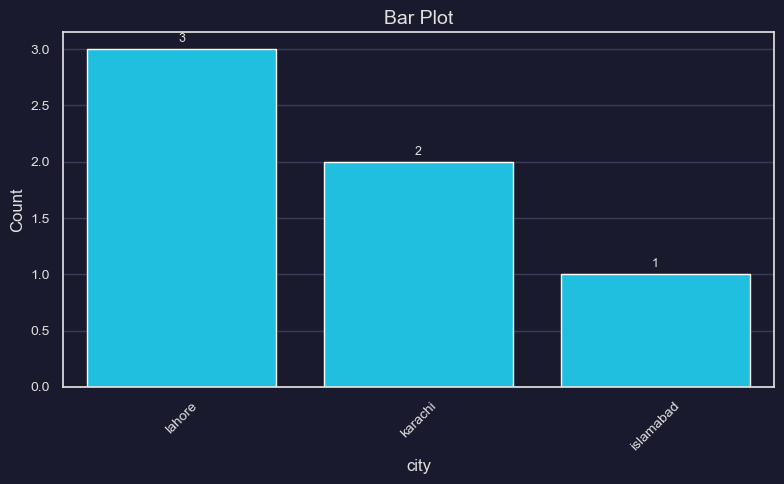

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Bar Plot'}, xlabel='city', ylabel='Count'>)

In [9]:
dsbro.viz.bar(train, x="city", show=True)


## Step 5 - Train a baseline model leaderboard

For quick tabular baselines, `dsbro.ml.compare()` gives you a ranked model table.


In [10]:
leaderboard = dsbro.ml.compare(featured.drop(columns=["bio"]), target="purchased", cv=2)
leaderboard.head()


,model,task,status,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,mcc_mean,mcc_std,cohen_kappa_mean,cohen_kappa_std,auc_mean,auc_std,log_loss_mean,log_loss_std,primary_metric,error
0,KNN,classification,error,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Expected n_neighbors <= n_samples_fit, but n_n..."
1,GradientBoosting,classification,ok,0.8333,0.1667,0.8333,0.1667,1.00,0.00,0.9000,0.1000,0.50,0.50,0.5,0.5,1.000,0.000,0.3618,0.1742,accuracy,NaN
2,DecisionTree,classification,ok,0.8333,0.1667,1.0000,0.0000,0.75,0.25,0.8333,0.1667,0.75,0.25,0.7,0.3,0.875,0.125,6.0073,6.0073,accuracy,NaN
3,AdaBoost,classification,ok,0.8333,0.1667,0.8333,0.1667,1.00,0.00,0.9000,0.1000,0.50,0.50,0.5,0.5,0.750,0.250,0.4603,0.3333,accuracy,NaN
4,LogisticRegression,classification,ok,0.6667,0.0000,0.6667,0.0000,1.00,0.00,0.8000,0.0000,0.00,0.00,0.0,0.0,1.000,0.000,0.5522,0.0877,accuracy,NaN


## Next steps

- Replace the synthetic data with your real training set.
- Use `dsbro.help()` to explore modules and function signatures.
- Try `dsbro.text.tfidf_features()` for text-heavy tabular problems.
